<a href="https://colab.research.google.com/github/RonnyBartsch-BIU/Adriatica-Summer-School-2026/blob/main/Adriatica2026_Tutorial_Bartsch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physiological Coupling in Practice
## From Cardiorespiratory Synchrony to Heart-Brain Interactions

**Adriatica Summer School 2026 — Hands-on Tutorial**
Ronny Bartsch, Department of Physics, Bar-Ilan University

The plan — three sensors, one set of methods:

| | Sensor | What we extract |
|---|---|---|
| 1–2 | **Smartphone** on chest | heartbeat, breathing, RSA, first synchrogram |
| 3 | **A wristwatch** (SOMNOwatch, as in the German National Cohort) | pulse waves + respiration from wrist motion alone |
| 4–5 | **Sleep-lab polysomnography** | synchronization across sleep stages, directed heart-brain coupling |

No installation needed — everything runs here in Google Colab.
*All data & this notebook:* `github.com/RonnyBartsch-BIU/Adriatica-Summer-School-2026`

In [2]:
# Setup: standard scientific Python only - nothing to install
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, hilbert
from scipy.interpolate import interp1d

plt.rcParams.update({'figure.figsize': (12, 4), 'font.size': 12})

BASE = "https://raw.githubusercontent.com/RonnyBartsch-BIU/Adriatica-Summer-School-2026/main/"

def bandpass(x, low, high, fs, order=3):
    """Zero-phase Butterworth bandpass filter."""
    b, a = butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return filtfilt(b, a, x)

---
# Block 1 — Your heartbeat, from your phone

A phone lying on your chest measures the tiny recoil vibrations of each heartbeat -
**seismocardiography (SCG)**. This recording was made with the free [Phyphox](https://phyphox.org)
app ("Acceleration with g"), lying supine, phone on the sternum, ~5-6 min of spontaneous breathing.

The same sensor also rises and falls with **breathing** -> one recording, two physiological
signals at very different time scales.

In [3]:
# Load the Phyphox export from GitHub
df = pd.read_csv(BASE + "spontaneous-breathing.csv")
df.head()

,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.010083,0.459422,9.585648,1.612762,9.731224
1,0.012171,0.449851,9.556933,1.607977,9.701697
2,0.014260,0.454636,9.552148,1.627119,9.700399
3,0.016350,0.445065,9.542577,1.631905,9.691335
4,0.018440,0.430708,9.537791,1.607977,9.681971


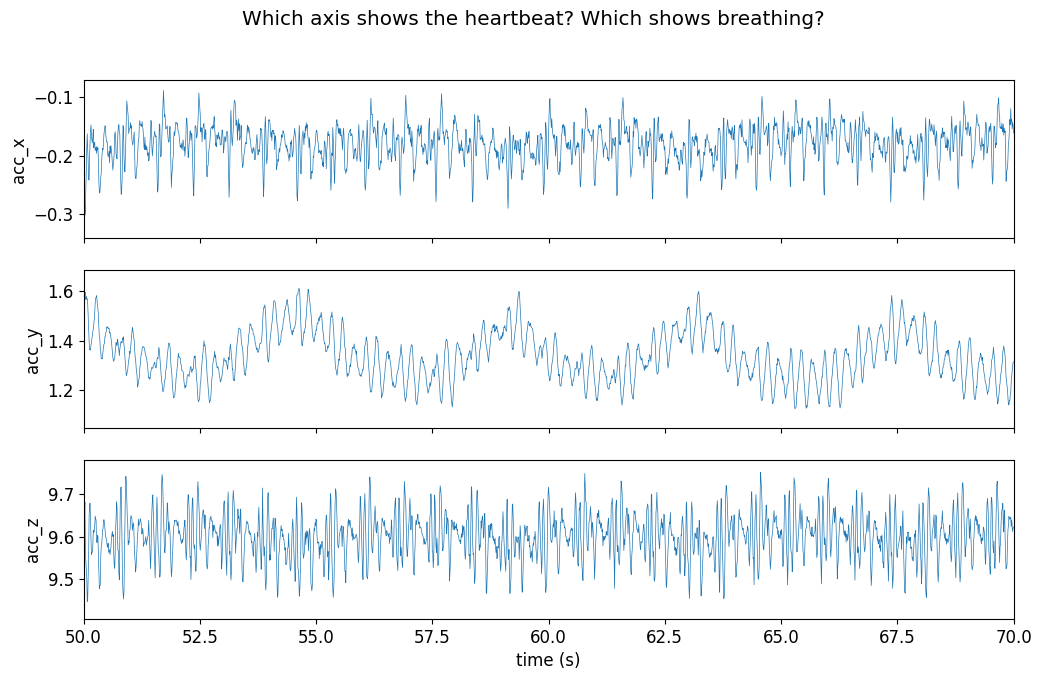

In [4]:
# Resample to a uniform 100 Hz grid (Phyphox samples at ~480 Hz, not perfectly uniform)
# and trim the first/last 15 s (placing the phone / reaching to stop the recording)
t_raw = df.iloc[:, 0].values
fs = 100.0
t = np.arange(t_raw[0] + 15, t_raw[-1] - 15, 1/fs)
acc_x, acc_y, acc_z = (interp1d(t_raw, df.iloc[:, i].values)(t) for i in (1, 2, 3))

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, sig, name in zip(axes, [acc_x, acc_y, acc_z], ["acc_x", "acc_y", "acc_z"]):
    ax.plot(t, sig, lw=0.5); ax.set_ylabel(name)
axes[-1].set_xlabel("time (s)"); axes[0].set_xlim(50, 70)
plt.suptitle("Which axis shows the heartbeat? Which shows breathing?");

**acc_z** sits near +9.8 m/s² — gravity: the phone lies flat on the chest — and carries the
sharpest heartbeat spikes. **acc_y** oscillates slowly: as the chest rises and falls, the
gravity projection on the phone's y axis changes with every breath.

### Detect the heartbeats
SCG beats are brief 5–25 Hz vibration bursts. We isolate that band, take the **envelope**
(one smooth hump per beat), and find its peaks. *Remember this trick — you will see it again.*

512 beats detected in 374 s


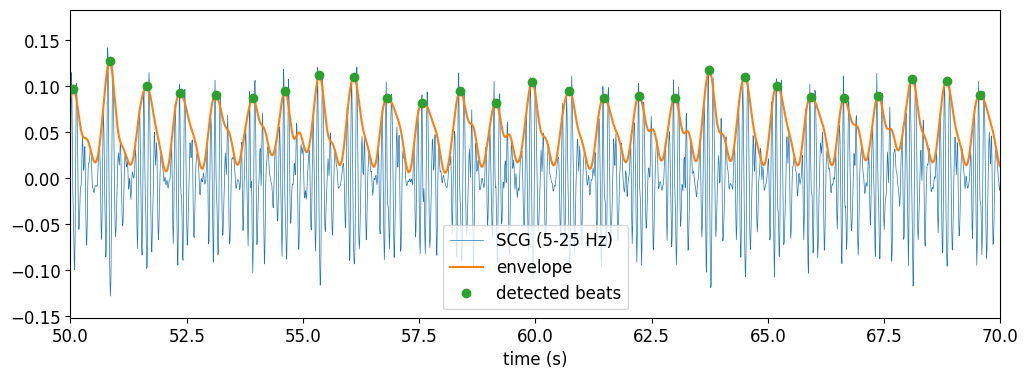

In [5]:
scg = bandpass(acc_z, 5, 25, fs)                     # isolate heartbeat vibrations
env = np.abs(hilbert(scg))                            # envelope: one hump per beat
env = filtfilt(*butter(3, 3/(fs/2)), env)             # smooth it
peaks, _ = find_peaks(env, distance=0.5*fs, prominence=0.5*env.std())
beat_times = t[peaks]

plt.plot(t, scg, lw=0.5, label="SCG (5-25 Hz)")
plt.plot(t, env, lw=1.5, label="envelope")
plt.plot(beat_times, env[peaks], 'o', label="detected beats")
plt.xlim(50, 70); plt.xlabel("time (s)"); plt.legend()
print(f"{len(beat_times)} beats detected in {t[-1]-t[0]:.0f} s")

mean HR = 82.1 bpm   |   0 intervals rejected


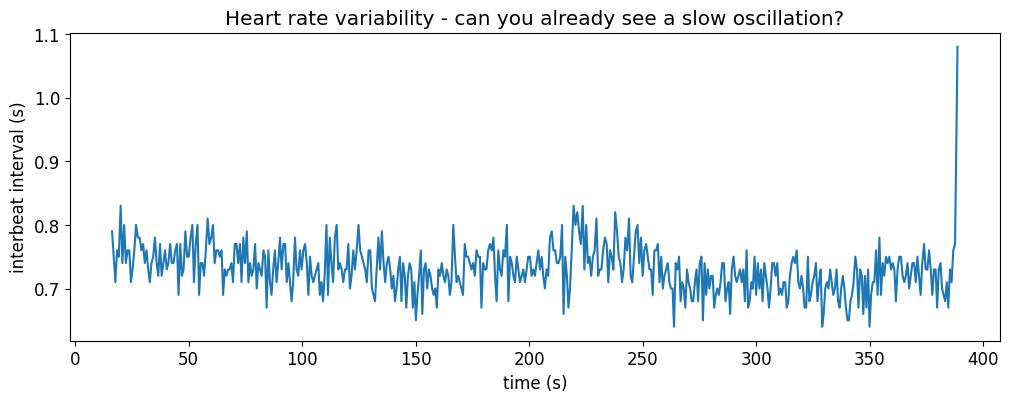

In [6]:
# Beat-to-beat intervals (the SCG analog of ECG RR intervals)
rri = np.diff(beat_times)
good = (rri > 0.4) & (rri < 1.6)          # reject implausible intervals (missed/double beats)
print(f"mean HR = {60/rri[good].mean():.1f} bpm   |   {np.sum(~good)} intervals rejected")

plt.plot(beat_times[1:][good], rri[good])
plt.xlabel("time (s)"); plt.ylabel("interbeat interval (s)")
plt.title("Heart rate variability - can you already see a slow oscillation?");

> **Question for the room:** the interbeat interval oscillates with a period of ~4–5 s.
> What physiological process has that time scale?

---
# Block 2 — Breathing, two ways: RSA in action

We extract breathing **twice, from independent sources**:

| Estimate | Source | Mechanism |
|---|---|---|
| `breath_acc` | acc_y | chest wall movement (direct, mechanical) |
| `breath_rri` | interbeat intervals | **respiratory sinus arrhythmia** — HR speeds up on inspiration, slows on expiration |

If RSA is real, a signal derived *only from heartbeat timing* should track the *mechanically measured* breathing.

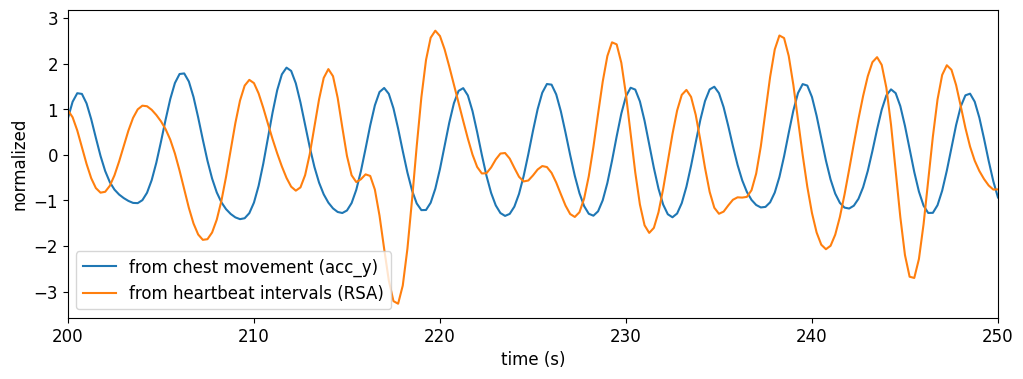

In [7]:
fs_r = 4.0   # ~12-16 samples per breathing cycle (3-4 s) - enough for a stable
             # Hilbert phase; more is pointless: RRI gives only ~1 sample per heartbeat
t4 = np.arange(beat_times[1], beat_times[-2], 1/fs_r)

# breathing band: 0.1-0.4 Hz covers typical adult rates (6-24 breaths/min)
lband = 0.1
hband = 0.4

breath_acc = bandpass(acc_y, lband, hband, fs)             # direct: chest movement
breath_acc4 = interp1d(t, breath_acc)(t4)

rri_i = interp1d(beat_times[1:], rri)(t4)              # indirect: RSA
breath_rri = bandpass(rri_i - rri_i.mean(), lband, hband, fs_r)

for sig, lbl in [(breath_acc4, "from chest movement (acc_y)"), (breath_rri, "from heartbeat intervals (RSA)")]:
    plt.plot(t4, sig/sig.std(), label=lbl)
plt.xlim(200, 250); plt.xlabel("time (s)"); plt.ylabel("normalized"); plt.legend();

### Quantify the agreement: instantaneous phase + synchronization index

The Hilbert transform assigns each oscillatory signal an instantaneous **phase** $\varphi(t)$.
The **phase synchronization index**
$$\gamma = \left| \langle e^{\,i(\varphi_1 - \varphi_2)} \rangle \right| \in [0, 1]$$
is 1 for perfect phase locking, ~0 for independent signals.

phase synchronization index = 0.509


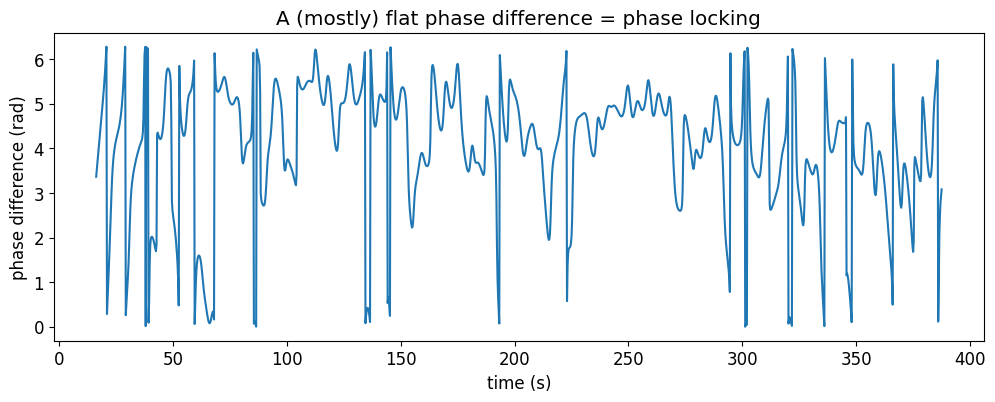

In [8]:
phi_acc = np.unwrap(np.angle(hilbert(breath_acc4)))
phi_rri = np.unwrap(np.angle(hilbert(breath_rri)))

psi = np.abs(np.mean(np.exp(1j*(phi_acc - phi_rri))))
print(f"phase synchronization index = {psi:.3f}")

plt.plot(t4, (phi_acc - phi_rri) % (2*np.pi)) # modulo 2\pi to wrap into [0,2\pi) interval -> phase jumps]
plt.xlabel("time (s)"); plt.ylabel("phase difference (rad)")
plt.title("A (mostly) flat phase difference = phase locking");

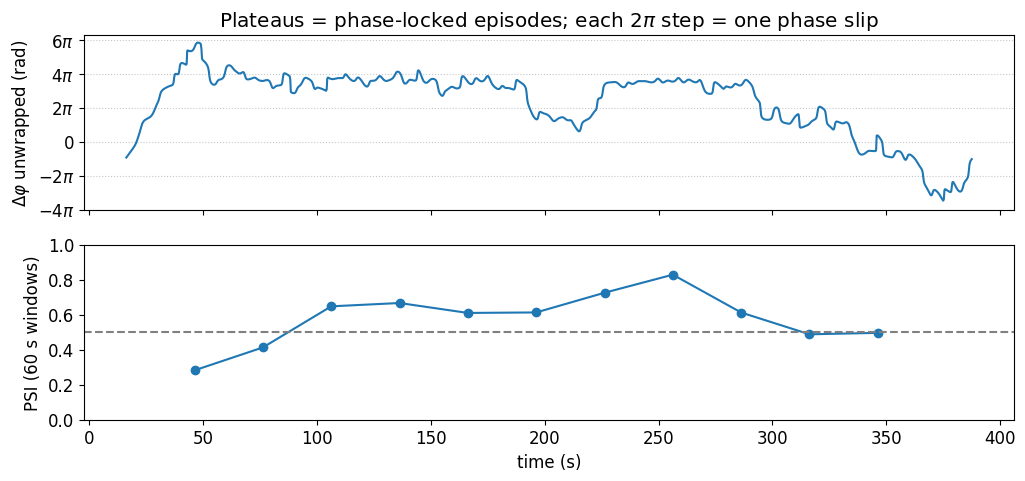

In [9]:
dphi = phi_acc - phi_rri
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t4, dphi)
ticks = 2*np.pi*np.arange(-2, 4)              # -4π ... +6π in steps of 2π
axes[0].set_yticks(ticks,
                   [rf"${k}\pi$" if k else "0" for k in range(-4, 8, 2)])
axes[0].grid(axis="y", ls=":", alpha=0.7)     # the countable levels
axes[0].set_ylabel(r"$\Delta\varphi$ unwrapped (rad)")
axes[0].set_title(r"Plateaus = phase-locked episodes; each $2\pi$ step = one phase slip")

# windowed PSI: where is the coupling actually strong?
w = int(60*fs_r)
psi_w = [np.abs(np.mean(np.exp(1j*dphi[i:i+w]))) for i in range(0, len(dphi)-w, w//2)]
t_w = t4[np.arange(0, len(dphi)-w, w//2) + w//2]
axes[1].plot(t_w, psi_w, 'o-')
axes[1].set_ylabel("PSI (60 s windows)"); axes[1].set_xlabel("time (s)")
axes[1].set_ylim(0, 1); axes[1].axhline(0.5, ls='--', color='gray');

> **Try it:** the PSI depends on the analysis band. Narrow the bandpass around the *observed*
> breathing frequency (here ~13 breaths/min ≈ 0.22 Hz, e.g. 0.15–0.3 Hz) and re-run — the PSI
> rises noticeably. Filtering choices are analysis choices; make them consciously.

Same heart, same phone — different breathing. In the second recording, breathing was paced by a metronome, much slower than normal. Look at the y-axis: the heart-rate swing per breath is several times larger. Why slow breathing amplifies RSA — and a filtering surprise on the way — is Exercise A.

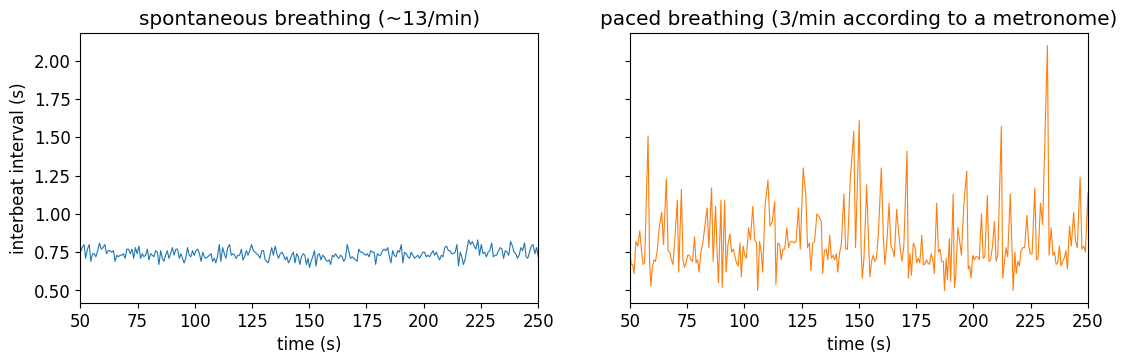

In [10]:
df_p = pd.read_csv(BASE + "paced-breathing.csv")
t_raw_p = df_p.iloc[:, 0].values
t_p = np.arange(t_raw_p[0] + 15, t_raw_p[-1] - 15, 1/fs)
acc_z_p = interp1d(t_raw_p, df_p.iloc[:, 3].values)(t_p)

scg_p = bandpass(acc_z_p, 5, 25, fs)
env_p = np.abs(hilbert(scg_p)); env_p = filtfilt(*butter(3, 3/(fs/2)), env_p)
pk_p, _ = find_peaks(env_p, distance=0.5*fs, prominence=0.5*env_p.std())
bt_p = t_p[pk_p]; rri_p = np.diff(bt_p)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), sharey=True)
axes[0].plot(beat_times[1:], rri, lw=0.8)
axes[0].set_title("spontaneous breathing (~13/min)")
axes[1].plot(bt_p[1:], rri_p, lw=0.8, color="tab:orange")
axes[1].set_title("paced breathing (3/min according to a metronome)")
for ax in axes:
    ax.set_xlabel("time (s)"); ax.set_xlim(50, 250)
axes[0].set_ylabel("interbeat interval (s)");
#plt.xlim(100, 120);
#plt.ylim(0.5, 1.5);

### The synchrogram: heartbeats inside the breathing cycle

Now the *n:m* question directly: **at which phase of the breathing cycle do individual
heartbeats occur?** Plot each heartbeat's respiratory phase (wrapped over 1 cycle) against
time. Horizontal bands = the heart consistently fires at fixed points of the breathing cycle:
**cardiorespiratory phase synchronization.**

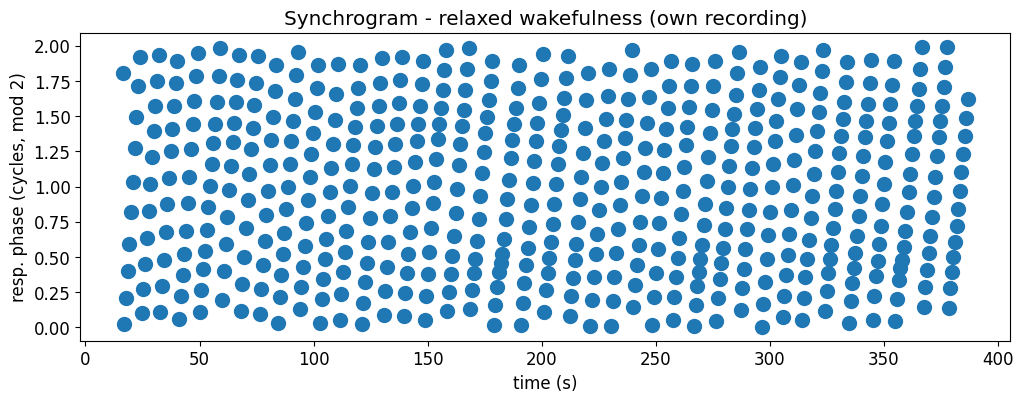

In [11]:
def synchrogram(beats, t_phase, phi, m=2, ax=None, **kw):
    """Respiratory phase (wrapped over m cycles) at each heartbeat time."""
    ph = interp1d(t_phase, phi, bounds_error=False)(beats)
    ok = ~np.isnan(ph)
    ax = ax or plt.gca()
    ax.plot(beats[ok], (ph[ok] % (2*np.pi*m)) / (2*np.pi), '.', ms=20, **kw)
    ax.set_xlabel("time (s)"); ax.set_ylabel(f"resp. phase (cycles, mod {m})")
    #plt.xlim(180, 280);
    return ax

synchrogram(beat_times, t4, phi_acc)
plt.title("Synchrogram - relaxed wakefulness (own recording)");

During relaxed wakefulness synchronization is **intermittent and weak** — short, drifting
episodes of banding at best. Keep this picture in mind for Block 4.

~24 heartbeats per breathing cycle


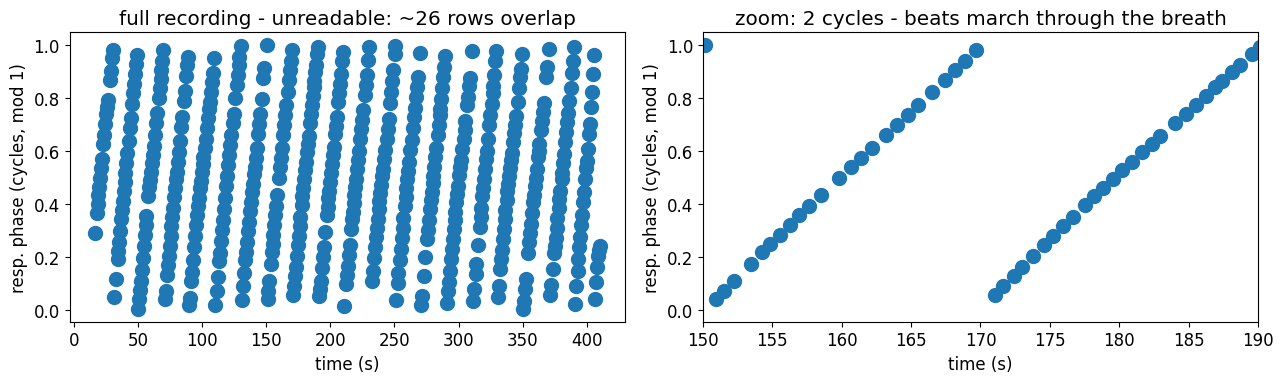

In [12]:
# @title
# --- Solution: synchrogram for paced breathing (3 breaths/min) ---
df_p = pd.read_csv(BASE + "paced-breathing.csv")
t_raw_p = df_p.iloc[:, 0].values
t_p = np.arange(t_raw_p[0] + 15, t_raw_p[-1] - 15, 1/fs)
acc_y_p = interp1d(t_raw_p, df_p.iloc[:, 2].values)(t_p)
acc_z_p = interp1d(t_raw_p, df_p.iloc[:, 3].values)(t_p)

# beats: same pipeline as Block 1
scg_p = bandpass(acc_z_p, 5, 25, fs)
env_p = np.abs(hilbert(scg_p)); env_p = filtfilt(*butter(3, 3/(fs/2)), env_p)
pk_p, _ = find_peaks(env_p, distance=0.5*fs, prominence=0.5*env_p.std())
bt_p = t_p[pk_p]

# breathing phase: band must cover 0.05 Hz! (the Exercise A filter fix)
fs_r = 4.0
t4_p = np.arange(bt_p[1], bt_p[-2], 1/fs_r)
breath_p = interp1d(t_p, bandpass(acc_y_p, 0.03, 0.1, fs))(t4_p)
phi_p = np.unwrap(np.angle(hilbert(breath_p)))

n_ratio = len(bt_p) / ((phi_p[-1] - phi_p[0]) / (2*np.pi))
print(f"~{n_ratio:.0f} heartbeats per breathing cycle")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
synchrogram(bt_p, t4_p, phi_p, m=1, ax=axes[0])
axes[0].set_title("full recording - unreadable: ~26 rows overlap")
synchrogram(bt_p, t4_p, phi_p, m=1, ax=axes[1])
axes[1].set_xlim(150, 190)                       # ~2 breathing cycles (20 s each)
axes[1].set_title("zoom: 2 cycles - beats march through the breath")
plt.tight_layout();

---
# Block 3 (demo) — The same trick, at scale: a wristwatch instead of a phone

**SOMNOwatch**: a watch-like device recording 3D wrist actigraphy, 1-channel ECG and nasal airflow. It is used for sleep analysis in the
**German National Cohort (NAKO)** — ~60,000 24-h recordings (during sleep, sleep stage are
classified from ECG and actigraphy using a CNN — a story for another day).

Question: Can a *wrist* sensor see the heartbeat? Yes: each pulse wave passing through the wrist causes
tiny ~8 Hz tissue vibrations, *amplitude-modulated* by the pulse — like a radio carrier wave.
The pipeline is **identical to Block 1**: bandpass → Hilbert envelope → smoothing.
(Zschocke et al., *IEEE Trans. Biomed. Eng.* 69:830, 2022 — 226 subjects, validated against ECG.)

Below: a 10-min sleep excerpt from a 24-h SOMNOwatch recording (3-axis wrist acceleration,
128 Hz) with simultaneously recorded ECG R-peaks as ground truth.

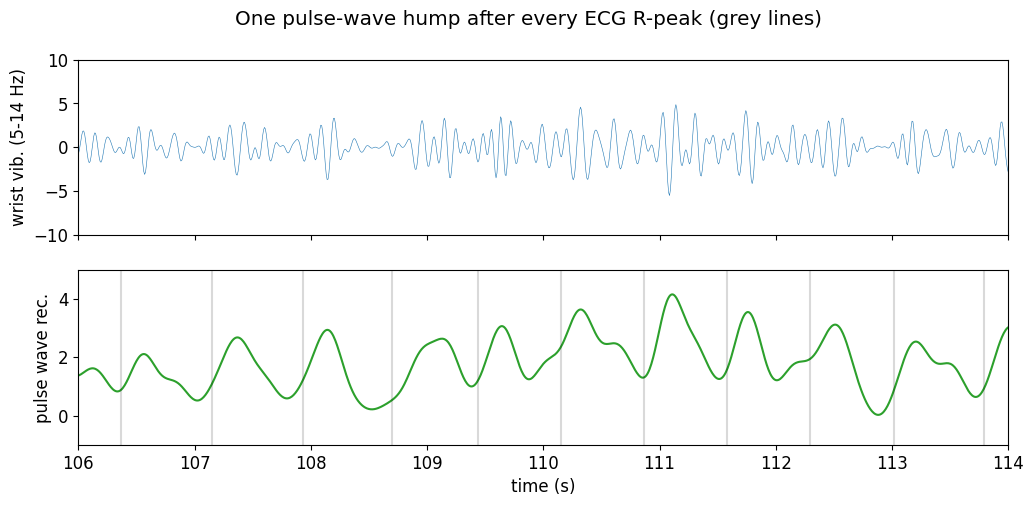

In [13]:
sw = pd.read_csv(BASE + "somnowatch_sleep.csv")        # time_s, acc_x, acc_y, acc_z @ 128 Hz
rp_ecg = np.loadtxt(BASE + "somnowatch_rpeaks.txt")    # reference ECG R-peak times (s)
fs_w = 128.0

vib = bandpass(sw.acc_z.values, 5, 14, fs_w)           # pulse-wave vibrations (5-14 Hz)
pw  = np.abs(hilbert(vib))                             # envelope = pulse wave reconstruction
pw  = filtfilt(*butter(3, 2.5/(fs_w/2)), pw)           # smooth away reflections from the hand

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(sw.time_s, vib, lw=0.4); axes[0].set_ylabel("wrist vib. (5-14 Hz)")
axes[0].set_ylim(-10,10)
axes[1].plot(sw.time_s, pw, color="tab:green"); axes[1].set_ylabel("pulse wave rec.")
for rp in rp_ecg:
    axes[1].axvline(rp, color="k", alpha=0.15)
axes[1].set_xlim(106, 114); axes[1].set_xlabel("time (s)")
axes[1].set_ylim(-1,5)
plt.suptitle("One pulse-wave hump after every ECG R-peak (grey lines)");

In [14]:
# Validate against the ECG: phase synchronization between reconstruction and R-peaks
phi_pw  = np.unwrap(np.angle(hilbert(pw - pw.mean())))
phi_ecg = interp1d(rp_ecg, 2*np.pi*np.arange(len(rp_ecg)), bounds_error=False)(sw.time_s.values)
ok = ~np.isnan(phi_ecg)
psi_pw = np.abs(np.mean(np.exp(1j*(phi_pw[ok] - phi_ecg[ok]))))
print(f"PSI pulse-wave reconstruction vs ECG = {psi_pw:.2f}")
print("Cohort distribution in Zschocke et al. 2022: mean ~0.70, range ~0.42–0.85 — this single 10-min excerpt from a 2016 recording sits right inside it.")

PSI pulse-wave reconstruction vs ECG = 0.59
Cohort distribution in Zschocke et al. 2022: mean ~0.70, range ~0.42–0.85 — this single 10-min excerpt from a 2016 recording sits right inside it.


> One wrist sensor → heartbeat *and* breathing (the same acc channels, 1-s moving average,
> also give a respiration reconstruction). This is how cardiorespiratory physiology becomes
> measurable in **cohorts of tens of thousands** — no electrodes, no sleep lab.

---
# Block 4 — Sleep changes everything: synchrograms across sleep stages

Now full **polysomnography** (SIESTA database, EU project — de-identified segments):
respiration + ECG R-peak times during **REM** and **deep sleep** of the same subject.

From the lecture: cardiorespiratory synchronization increases by ~**400 % from REM to deep sleep**.

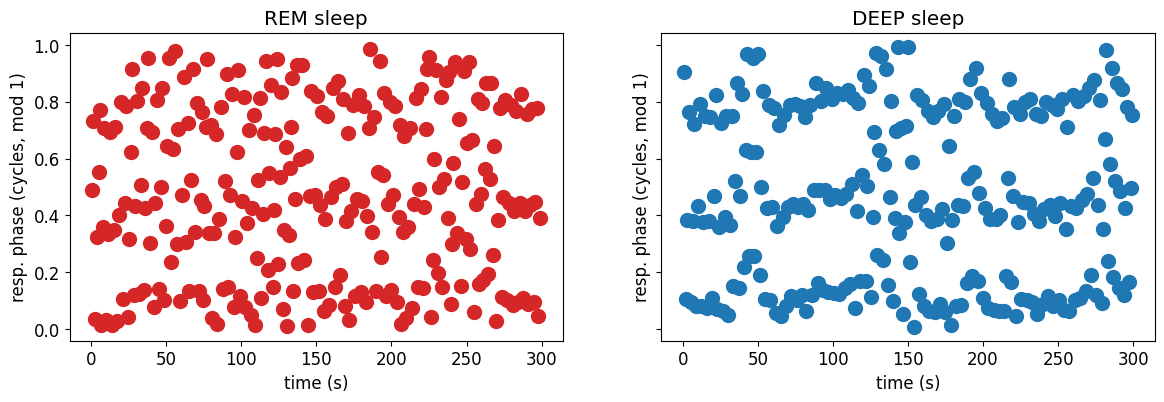

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, stage, color in zip(axes, ["rem", "deep"], ["tab:red", "tab:blue"]):
    seg = pd.read_csv(BASE + f"siesta_{stage}.csv")           # time_s, resp (4 Hz)
    rp = np.loadtxt(BASE + f"siesta_{stage}_rpeaks.txt")      # R-peak times (s)
    resp = bandpass(seg.resp.values, 0.08, 0.6, 4.0)
    phi = np.unwrap(np.angle(hilbert(resp)))
    synchrogram(rp, seg.time_s.values, phi, m=1, ax=ax, color=color)
    ax.set_title(f"{stage.upper()} sleep")
    #axes[0].set_xlim(60, 120);
    #axes[1].set_xlim(60, 120);

**Deep sleep:** clear horizontal bands — the heart beats at preferred phases of the breathing
cycle. **REM:** the points smear — no stable phase relationship.

> **Discussion:** the *average heart rate is nearly identical* in both stages. What does that
> tell you about the difference between *rate* coupling and *phase* coupling?

--> Mean heart rate and mean breathing rate barely change between REM and deep sleep, thus every rate-based measure (mean HR, standard HRV indices) sees almost nothing here
--> What changes is the stability of the relative phase. Coupling can reorganize completely while the individual signals look unchanged; you have to look at the interaction itself to see it.

---
# Block 5 (demo) — Direction matters: heart-brain coupling via Granger causality

Everything so far is **symmetric**: a synchrogram cannot tell you *who drives whom*.
**Granger causality** can, with one idea:

> **z G-causes x** *if knowing the past of z improves the prediction of x.*

$G_{z \to x} = \ln(\sigma^2_{\text{without } z} / \sigma^2_{\text{with } z}) \geq 0$ — zero if *z* adds nothing.

Data: **heart rate** and **EEG α-band amplitude** (1 Hz) from a light-sleep episode
(SIESTA; method: [Günther, Kantelhardt & Bartsch, *Front. Netw. Physiol.* 2022](https://doi.org/10.3389/fnetp.2022.893743)).
We just run it — the function below is 15 lines, read it later.

light: G(EEGα→HR)=0.0696  G(HR→EEGα)=0.0096  surrogate 95% = 0.0140
deep: G(EEGα→HR)=0.0071  G(HR→EEGα)=0.0012  surrogate 95% = 0.0126


Text(0.98, 0.012599762133411558, ' surrogate 95%')

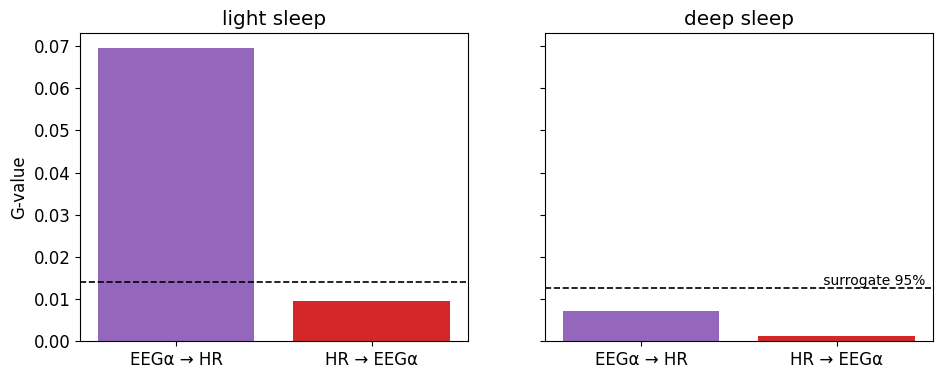

In [24]:
def granger_G(x, z, p=3):
    """G-value for z -> x with AR order p (pairwise Granger causality)."""
    x = (x - x.mean())/x.std();  z = (z - z.mean())/z.std()
    n = len(x)
    X_own = np.column_stack([x[p-i-1:n-i-1] for i in range(p)])     # past of x
    X_z   = np.column_stack([z[p-i-1:n-i-1] for i in range(p)])     # past of z
    y = x[p:]
    def resvar(A):
        A = np.column_stack([np.ones(len(y)), A])
        beta, *_ = np.linalg.lstsq(A, y, rcond=None)
        return np.var(y - A @ beta)
    return np.log(resvar(X_own) / resvar(np.hstack([X_own, X_z])))

def surrogate_threshold(x, z, p=3, n_surr=100, pct=95, seed=0):
    """95th-percentile G under circular shifts of z (coupling destroyed,
    autocorrelation of both signals preserved)."""
    rng = np.random.default_rng(seed)
    n = len(z)
    G_surr = [granger_G(x, np.roll(z, rng.integers(n//10, n - n//10)), p)
              for _ in range(n_surr)]
    return np.percentile(G_surr, pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, stage in zip(axes, ["light", "deep"]):
    g = pd.read_csv(BASE + f"siesta_granger_{stage}.csv")
    hr, eeg = g.hr.values, g.eeg_alpha.values

    G = [granger_G(hr, eeg), granger_G(eeg, hr)]
    thr = max(surrogate_threshold(hr, eeg), surrogate_threshold(eeg, hr))

    ax.bar(["EEGα → HR", "HR → EEGα"], G, color=["tab:purple", "tab:red"])
    ax.axhline(thr, ls="--", color="k", lw=1.2)
    ax.set_title(f"{stage} sleep")
    print(f"{stage}: G(EEGα→HR)={G[0]:.4f}  G(HR→EEGα)={G[1]:.4f}  "
          f"surrogate 95% = {thr:.4f}")

axes[0].set_ylabel("G-value")
axes[1].text(0.98, thr, " surrogate 95%", va="bottom", ha="right",
             transform=axes[1].get_yaxis_transform(), fontsize=10)
#plt.suptitle("Dashed line: what G looks like when the coupling is destroyed");
#plt.tight_layout()

Two observations, both matching the cohort results from the lecture:
1. **Asymmetry** — in light sleep, brain (EEG α) → heart clearly dominates the reverse direction.
2. **Deep-sleep decoupling** — both directions collapse: the physiological network disengages
   in the most restorative sleep stage.

*Caveat for real use:* Granger requires (quasi-)stationary segments — the full pipeline
(stationarity testing, segmentation, conditional analysis to exclude indirect links) is in
[Moritz Günther's repository](https://github.com/moritz-g/causal_networks_physiology).
For information-theoretic measures of directed coupling → **Yuri's workshop**.

---
# Wrap-up

| Step | Method | What it captures |
|---|---|---|
| Beat detection | bandpass + Hilbert envelope | cardiac timing — phone (chest) or watch (wrist) |
| Breathing from RRI | bandpass + RSA | one system *encoded in* another |
| PSI | Hilbert phase | strength of phase locking (symmetric) |
| Synchrogram | phase-of-beat plot | *n:m* locking, visible by eye, per sleep stage |
| Granger causality | AR forecasting | **direction** of coupling |

**Key messages**
1. Coupling is not one thing — RSA, phase synchronization, and causal influence are
   *coexisting, distinct* modes that change independently across sleep stages.
2. The same simple signal-processing trick (bandpass → envelope) scales from your phone
   to national-cohort wearables.
3. Direction requires *prediction*, not just correlation — and reveals that deep sleep
   decouples the heart-brain network while phase-locking heart and breathing.

**Record yourself tonight:** Phyphox → *Acceleration with g* → phone on sternum, 5 min lying
still → export CSV → re-run Blocks 1–2 on your own heartbeat.

---
# Take-home exercises

**A. Paced breathing.** The repo also contains `paced-breathing.csv`: same setup, but breathing
paced by a metronome at 6 clicks/min, starting an *inhale or exhale on each click* — i.e.
**3 breaths/min (0.05 Hz)**, ~4× slower than spontaneous. Repeat Blocks 1–2. First surprise:
with the default 0.08–0.5 Hz bandpass, the breathing signal *vanishes* — why? Fix the band
(try 0.03–0.1 Hz for both breathing estimates), then compare the RSA amplitude with the
spontaneous recording. You should find a several-fold amplification of the heart-rate swing
per breath — this frequency dependence of RSA is a well-known cardiovascular phenomenon.

**B. Locking ratio.** Count the bands in the deep-sleep synchrogram of Block 4. Which *n:1*
locking is this subject showing?

**C. Granger surrogate test.** Pair the HR of the light-sleep segment with the EEG of the
deep-sleep segment (different episodes → no true coupling). How large is G now? This is the
simplest surrogate test against spurious causality.

**D. Wrist respiration.** Following Zschocke et al. (2022): apply a 1-s moving average to the
SOMNOwatch acc channels, bandpass 0.08–0.5 Hz, and compare the respiratory phase across the
three axes. Which axis gives the most reliable breathing signal in this excerpt?

**References & tools**
Günther, Kantelhardt & Bartsch, *Front. Netw. Physiol.* 2:893743 (2022) ·
Zschocke et al., *IEEE TBME* 69:830 (2022) ·
Bartsch et al., *PLoS ONE* 10:e0142143 (2015) ·
TDS toolbox: [pypi.org/project/TDSpy](https://pypi.org/project/TDSpy/)